## In this notebook I load and explore sea lion data from SA
### I am trying to find if there is anything worth it for us to use. This notebook doesn't do any QAQC of these data. 

#### THINGS TO TRY:
#### - find mooring seals
#### - find transect seals and try an inshore transect (KI and Bonney)
#### - vertical profiles pressure vs salinity, coloured by T in both locations
#### - TS per month/per location as per above.
#### - a snapshot of the whole region every 100m. Try monthly, then just Nov-Apr (upwelling season), then year. 

### Import necessary packages

In [1]:
pip install cmocean

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import cartopy.crs as ccrs
import cartopy.feature as cf
import xarray as xr
import cmocean


from matplotlib.colors import Normalize
from matplotlib.colors import ListedColormap
from matplotlib.cm import ScalarMappable
from datetime import datetime


#### Load csv file that contains the sea lion data

In [2]:
# Replace 'your_file.csv' with the actual file path
file_path = r'C:\Users\nribeiro\OneDrive - University of Tasmania\IMOS Shared Docs\CAPSTAN 2025\Datasets\sea_lion_SA.csv'

#I had to add this line because I was getting an error while importing that this column had mixed types. 
dtype_options = {'device_wmo_ref': 'object'}


# Load the CSV file into a DataFrame
df = pd.read_csv(file_path, dtype=dtype_options)
# Display the DataFrame
df.head()



,FID,measurement_id,profile_id,file_id,sattag_program,device_id,device_wmo_ref,ptt,tag_type,common_name,...,lon,lat,pressure,temp_vals,sal_vals,sal_corrected_vals,fluoro_vals,cond_vals,geom,colour
0,aatams_sattag_dm_profile_data.fid--3dc5c2da_19...,98133430,6280425,22,ct101,ct101-790-13,Q9900594,129856,SMRU CTD tag,Australian Fur Seal,...,142.7240,-38.8914,NaN,NaN,35.747,35.747,NaN,NaN,POINT (142.723999453627 -38.8913879251468),#1C0EE2
1,aatams_sattag_dm_profile_data.fid--3dc5c2da_19...,98133449,6280426,22,ct101,ct101-790-13,Q9900594,129856,SMRU CTD tag,Australian Fur Seal,...,142.6852,-38.8729,4.0,15.1700,NaN,NaN,NaN,NaN,POINT (142.685152301598 -38.8728658653189),#1C0EE2
2,aatams_sattag_dm_profile_data.fid--3dc5c2da_19...,98133450,6280426,22,ct101,ct101-790-13,Q9900594,129856,SMRU CTD tag,Australian Fur Seal,...,142.6852,-38.8729,8.0,15.1569,NaN,NaN,NaN,NaN,POINT (142.685152301598 -38.8728658653189),#1C0EE2
3,aatams_sattag_dm_profile_data.fid--3dc5c2da_19...,98133451,6280426,22,ct101,ct101-790-13,Q9900594,129856,SMRU CTD tag,Australian Fur Seal,...,142.6852,-38.8729,12.0,15.1489,NaN,NaN,NaN,NaN,POINT (142.685152301598 -38.8728658653189),#1C0EE2
4,aatams_sattag_dm_profile_data.fid--3dc5c2da_19...,98133452,6280426,22,ct101,ct101-790-13,Q9900594,129856,SMRU CTD tag,Australian Fur Seal,...,142.6852,-38.8729,16.0,15.1449,NaN,NaN,NaN,NaN,POINT (142.685152301598 -38.8728658653189),#1C0EE2


#### Convert the time column to datetime format



In [3]:
df['time'] = pd.to_datetime(df['timestamp'], format='%Y-%m-%dT%H:%M:%SZ')


#### Extract month & year from the datetime column


In [4]:
df['month'] = df['time'].dt.month
df['year'] = df['time'].dt.year

#### Convert datetime values to numerical timestamps


In [5]:
df['time_numeric'] = df['time'].values.astype(float)

#### Convert datetime values to numerical timestamps using mdates.date2num


In [6]:
df['time_numeric'] = mdates.date2num(df['time'])

In [7]:
unique_years = df['year'].unique()
unique_month = df['month'].unique()

In [8]:
#we have 12 years available
unique_years

array([2013, 2014, 2015, 2016, 2017, 2018, 2008, 2007, 2009, 2010, 2011,
       2012], dtype=int64)

In [9]:
#we have 11 years available
unique_month

array([10, 11,  3,  4,  5,  6,  7,  2, 12,  1,  8], dtype=int64)

#### Making an histogram to understand how the data is on time

In [10]:
profiles_per_year = df.groupby('year')['profile_id'].nunique()
profiles_per_month = df.groupby('month')['profile_id'].nunique()

In [11]:
# Reindex months (so missing months show as 0)
months = np.arange(1, 13)
profiles_per_month = profiles_per_month.reindex(months, fill_value=0)

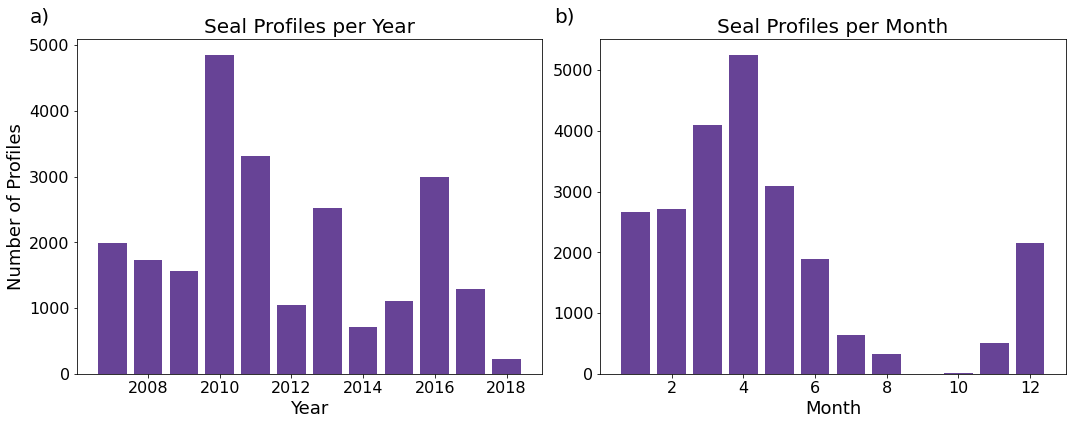

<Figure size 432x288 with 0 Axes>

In [17]:
import matplotlib.pyplot as plt
import cmocean.cm as cm

fig, axs = plt.subplots(1, 2, figsize=(15, 6))

# --- Year plot ---
axs[0].bar(profiles_per_year.index, profiles_per_year.values, color=cm.thermal(0.3))
axs[0].set_title('Seal Profiles per Year', fontsize=20)
axs[0].set_xlabel('Year', fontsize=18)
axs[0].set_ylabel('Number of Profiles', fontsize=18)
axs[0].tick_params(axis='both', labelsize=16)
axs[0].text(-0.1, 1.05, 'a)', transform=axs[0].transAxes, fontsize=20)

# --- Month plot ---
axs[1].bar(months, profiles_per_month.values, color=cm.thermal(0.3))
axs[1].set_title('Seal Profiles per Month', fontsize=20)
axs[1].set_xlabel('Month', fontsize=18)
axs[1].tick_params(axis='both', labelsize=16)
axs[1].text(-0.1, 1.05, 'b)', transform=axs[1].transAxes, fontsize=20)

plt.tight_layout()

#force rendering because of cartopy saving issues
plt.draw()  # force render
fig.savefig(filestr, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
# Save figure
figdir = r'C:\Users\nribeiro\OneDrive - University of Tasmania\IMOS Shared Docs\CAPSTAN 2025\CAPSTAN_HAB_work\Figures\\'  
filestr = figdir + 'seal_profiles_histogram.png'


#### Plot a map of profiles per year coloured by month. 

In [13]:
#reduce to one row per profile
profile_data_copy = df.groupby('profile_id').first().reset_index()

years = np.sort(profile_data_copy['year'].unique())

C:\Users\nribeiro\AppData\Local\Temp\ipykernel_34160\4183186580.py:87: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])  # leave space for the colorbar


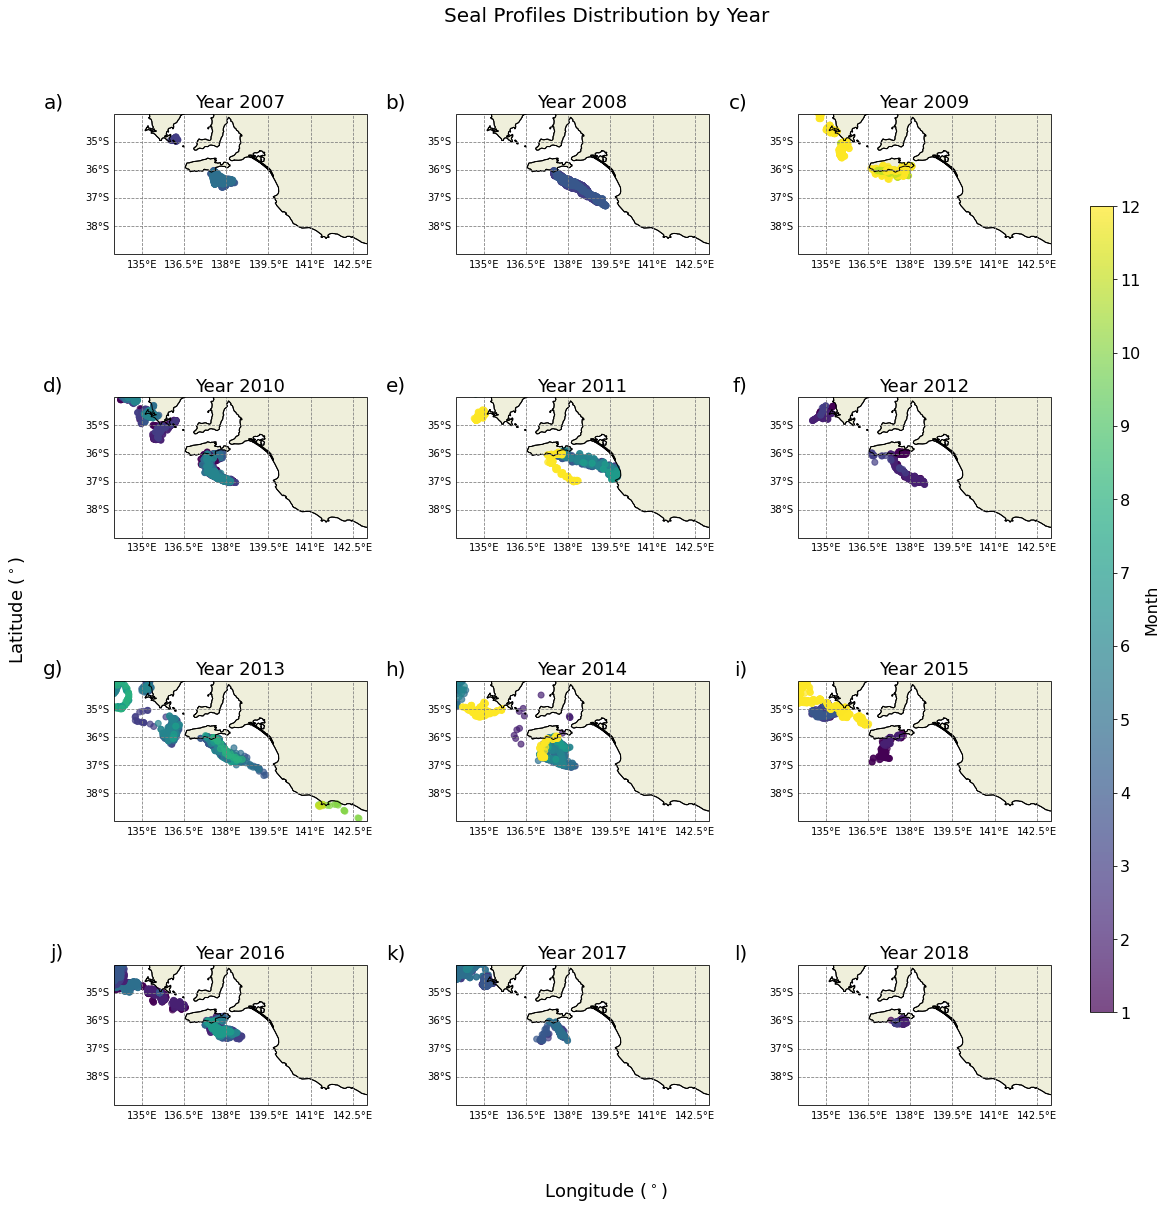

<Figure size 432x288 with 0 Axes>

In [16]:
import matplotlib.pyplot as plt
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# One row per profile (IMPORTANT)
profile_data_copy = df.groupby('profile_id').first().reset_index()

# Get available years dynamically
years = np.sort(profile_data_copy['year'].unique())

# Layout
num_years = len(years)
num_cols = 3
num_rows = -(-num_years // num_cols)  # Ceiling division

fig, axs = plt.subplots(
    num_rows, num_cols,
    figsize=(16, 16),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

alphabet = 'abcdefghijklmnopqrstuvwxyz'

for i, year in enumerate(years):

    ax = axs[i // num_cols, i % num_cols]
    ax.add_feature(cfeature.LAND, zorder=0, edgecolor='black')
    ax.coastlines()
    gl = ax.gridlines(draw_labels=True, linestyle='--', color='gray')
    gl.top_labels = False
    gl.right_labels = False

    # --- Data subset ---
    subset = profile_data_copy[profile_data_copy['year'] == year]

    if len(subset) > 0:

        lat_data = subset['lat'].values
        lon_data = subset['lon'].values
        month_data = subset['month'].values

        # Scatter
        scatter = ax.scatter(
            lon_data,
            lat_data,
            c=month_data,
            cmap='viridis',
            alpha=0.7,
            vmin=1, vmax=12,
            transform=ccrs.PlateCarree()
        )

        ax.set_title(f'Year {year}', fontsize=18)
        ax.tick_params(labelsize=16)
        ax.set_extent([134, 143, -39, -34], crs=ccrs.PlateCarree())

        # Subplot label
        ax.text(
            -0.2, 1.15, f'{alphabet[i]})',
            transform=ax.transAxes,
            fontsize=20,
            va='top',
            ha='right'
        )

    else:
        ax.set_visible(False)

# Hide unused subplots
for j in range(i + 1, num_rows * num_cols):
    axs.flat[j].set_visible(False)

# --- SINGLE COLORBAR ---
# Place it on the right side of all subplots
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
cbar = fig.colorbar(scatter, cax=cbar_ax, ticks=np.arange(1, 13))
cbar.set_label('Month', fontsize=16)
cbar.set_ticks(np.arange(1, 13))
cbar.set_ticklabels(np.arange(1, 13), fontsize=16)

# Global labels
fig.text(0.5, -0.01, 'Longitude ($^\circ$)', ha='center', fontsize=18)
fig.text(-0.02, 0.5, 'Latitude ($^\circ$)', va='center', rotation='vertical', fontsize=18)
fig.text(0.5, 1.01, 'Seal Profiles Distribution by Year', ha='center', fontsize=20)

plt.tight_layout(rect=[0, 0, 0.9, 1])  # leave space for the colorbar
plt.show()

#force rendering because of cartopy saving issues
plt.draw()  # force render
fig.savefig(filestr, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

# Save figure
figdir = r'C:\Users\nribeiro\OneDrive - University of Tasmania\IMOS Shared Docs\CAPSTAN 2025\CAPSTAN_HAB_work\Figures\\'  
filestr = figdir + 'seal_profiles_spread_loc&time.png'

## Making individual figures for all years


In [18]:
# --- Make sure you have one row per measurement (NOT grouped!) ---
data = df.copy()


In [19]:
print(data)

                                                      FID  measurement_id  \
0       aatams_sattag_dm_profile_data.fid--3dc5c2da_19...        98133430   
1       aatams_sattag_dm_profile_data.fid--3dc5c2da_19...        98133449   
2       aatams_sattag_dm_profile_data.fid--3dc5c2da_19...        98133450   
3       aatams_sattag_dm_profile_data.fid--3dc5c2da_19...        98133451   
4       aatams_sattag_dm_profile_data.fid--3dc5c2da_19...        98133452   
...                                                   ...             ...   
369391  aatams_sattag_dm_profile_data.fid--3dc5c2da_19...        92390260   
369392  aatams_sattag_dm_profile_data.fid--3dc5c2da_19...        92390261   
369393  aatams_sattag_dm_profile_data.fid--3dc5c2da_19...        92390262   
369394  aatams_sattag_dm_profile_data.fid--3dc5c2da_19...        92390263   
369395  aatams_sattag_dm_profile_data.fid--3dc5c2da_19...        92390264   

        profile_id  file_id sattag_program           device_id device_wmo_r

In [20]:
# Get available years
years = np.sort(data['year'].unique())

In [21]:
print(years)

[2007 2008 2009 2010 2011 2012 2013 2014 2015 2016 2017 2018]


In [22]:
list(df.columns)

['FID',
 'measurement_id',
 'profile_id',
 'file_id',
 'sattag_program',
 'device_id',
 'device_wmo_ref',
 'ptt',
 'tag_type',
 'common_name',
 'release_site',
 'state_country',
 'age_class',
 'sex',
 'timestamp',
 'lon',
 'lat',
 'pressure',
 'temp_vals',
 'sal_vals',
 'sal_corrected_vals',
 'fluoro_vals',
 'cond_vals',
 'geom',
 'colour',
 'time',
 'month',
 'year',
 'time_numeric']

In [39]:
df.groupby('year')['month'].unique()


year
2007                        [3, 4, 5]
2008                           [3, 4]
2009                         [11, 12]
2010            [1, 2, 3, 4, 5, 6, 7]
2011       [2, 3, 4, 5, 6, 7, 11, 12]
2012                        [1, 2, 3]
2013    [10, 11, 3, 4, 5, 6, 7, 2, 8]
2014           [3, 4, 5, 6, 7, 2, 12]
2015                 [12, 1, 2, 3, 4]
2016            [1, 2, 3, 4, 5, 6, 7]
2017                  [2, 3, 4, 5, 6]
2018                        [1, 2, 3]
Name: month, dtype: object

In [43]:
df['sal_corrected_vals'].describe()

count    83745.000000
mean        35.891703
std          0.303087
min         21.500000
25%         35.790000
50%         35.915000
75%         36.026000
max         37.232000
Name: sal_corrected_vals, dtype: float64

In [44]:
df['temp_vals'].describe()

count    366216.000000
mean         16.995826
std           1.650422
min           9.871000
25%          16.078000
50%          17.204000
75%          18.125025
max          27.002000
Name: temp_vals, dtype: float64

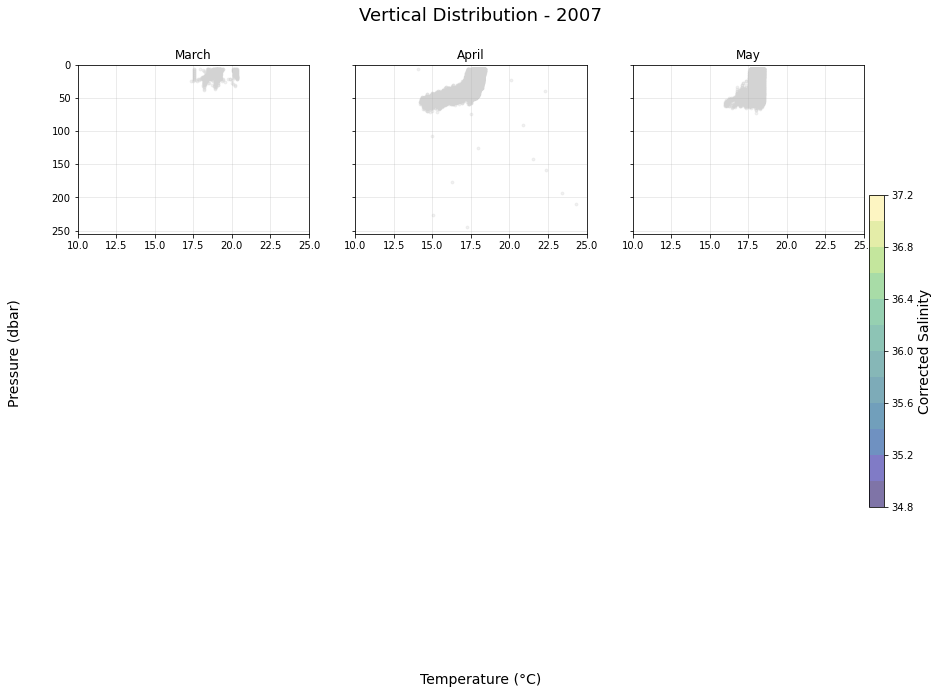

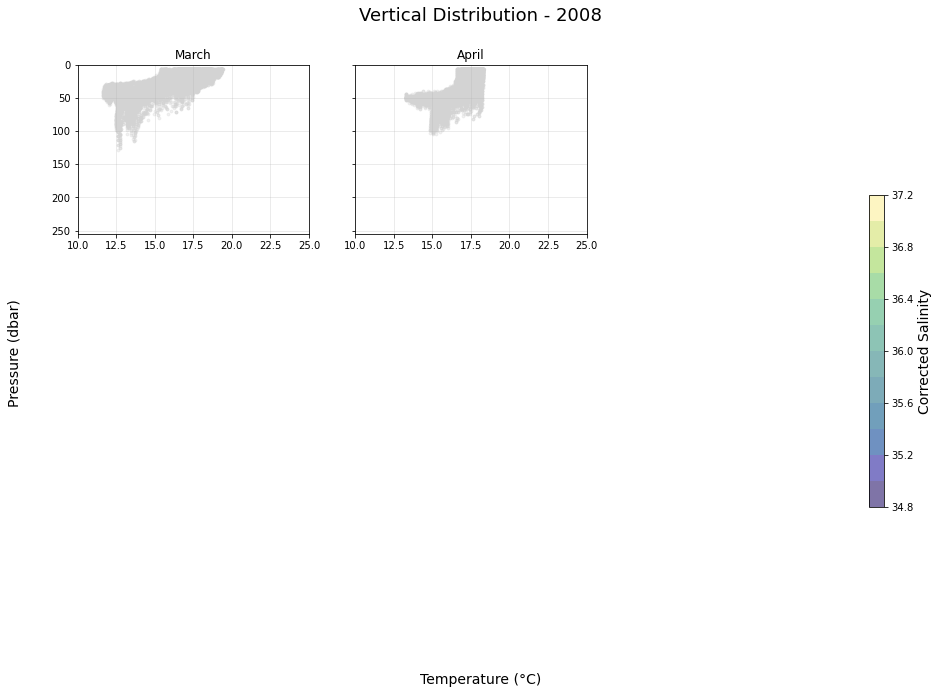

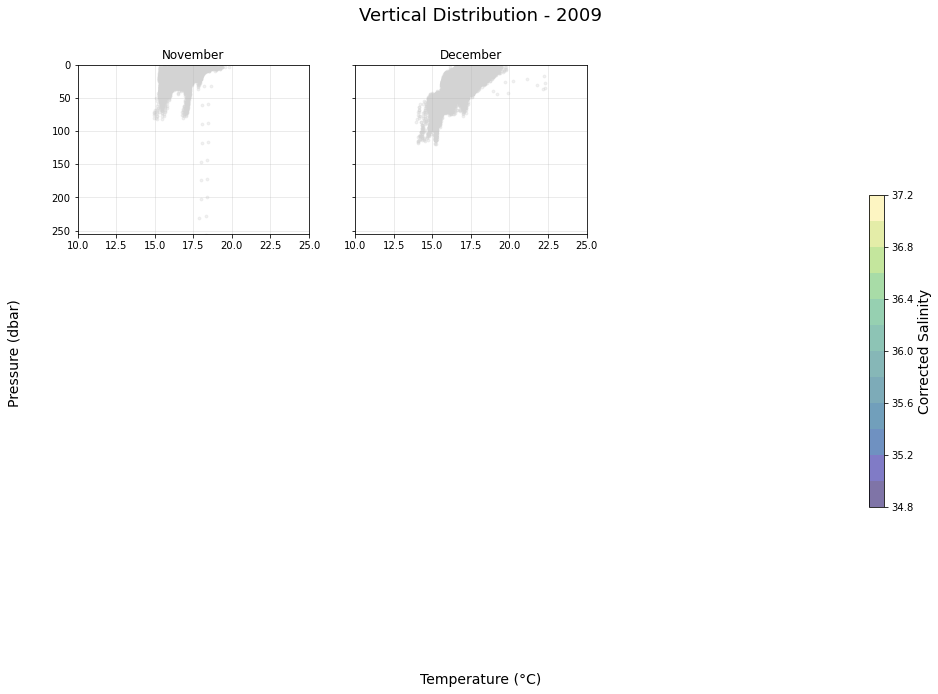

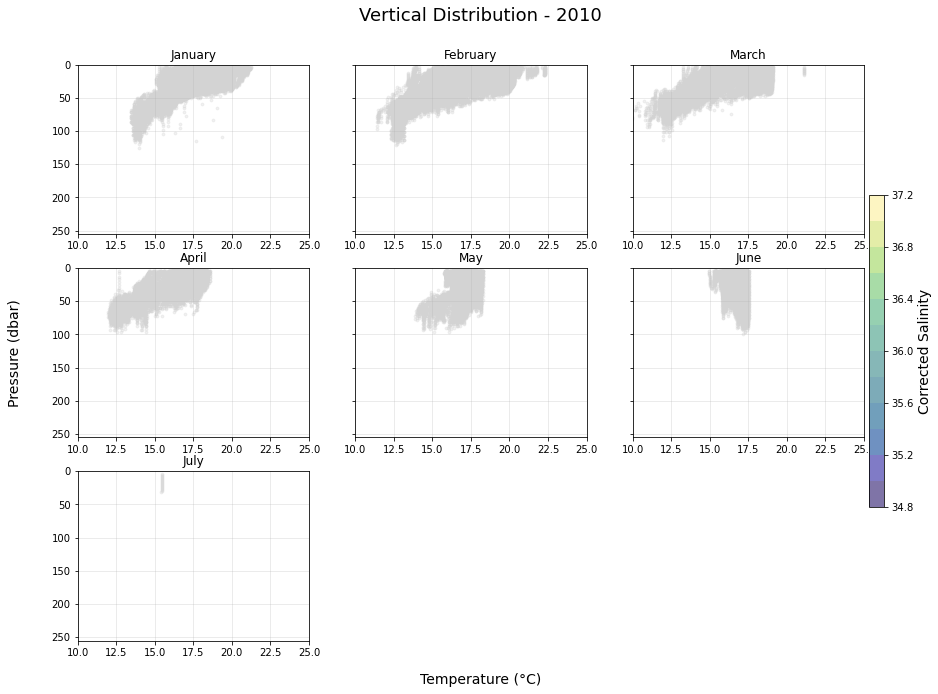

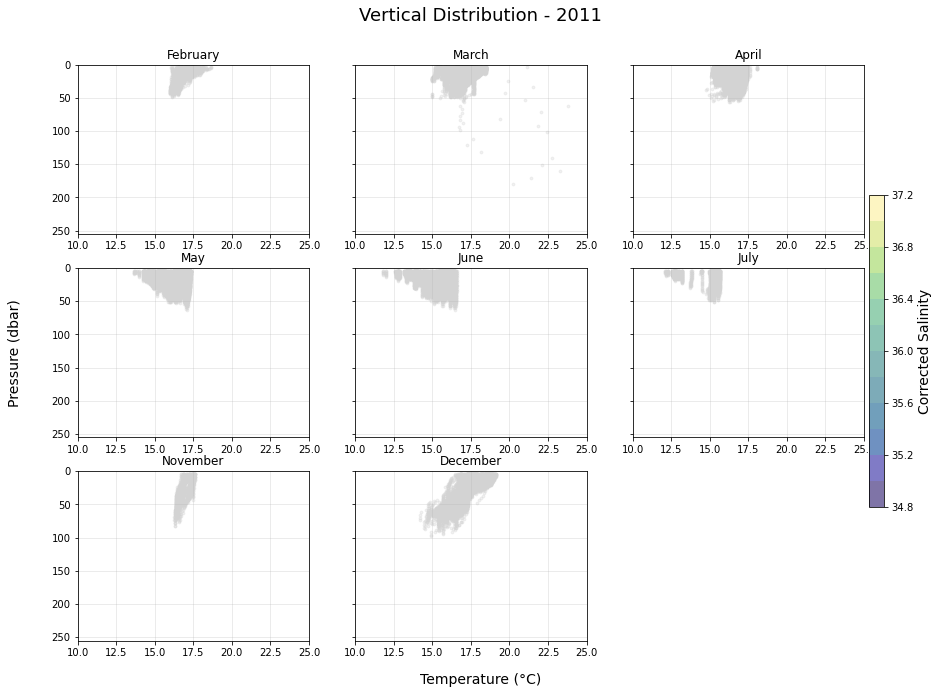

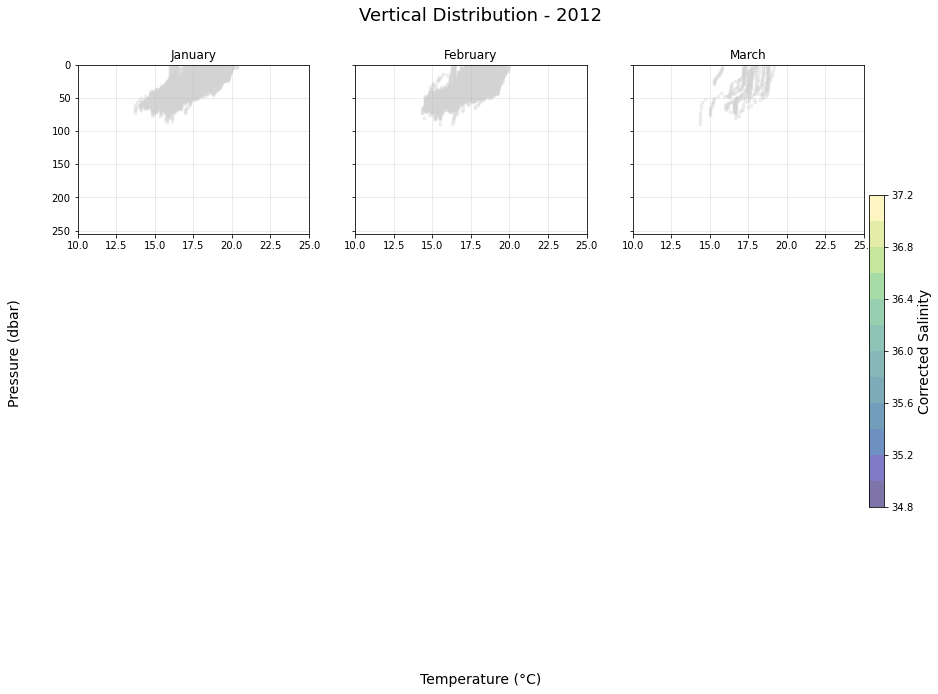

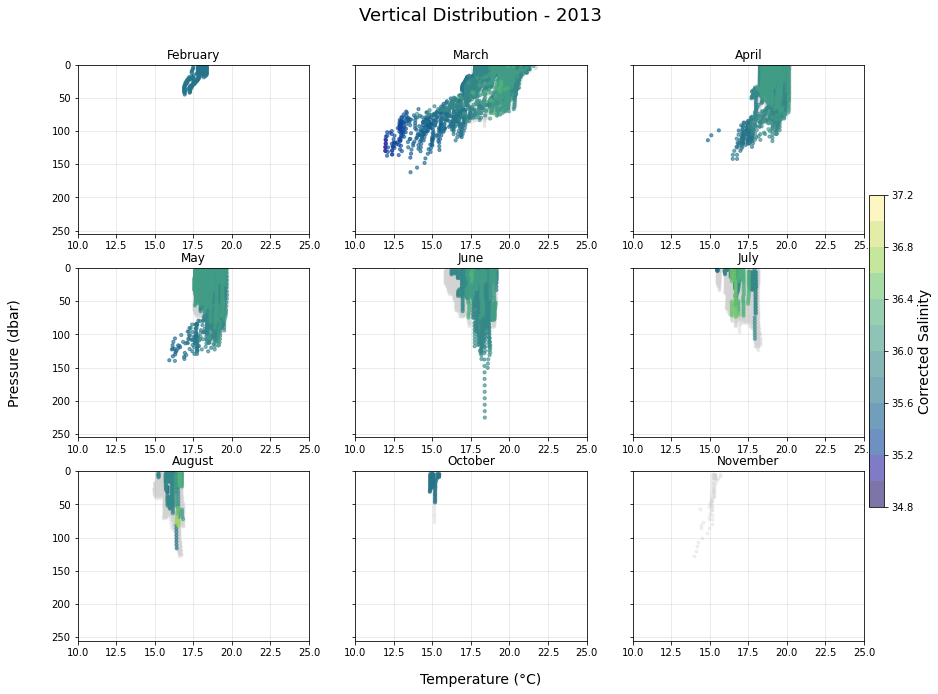

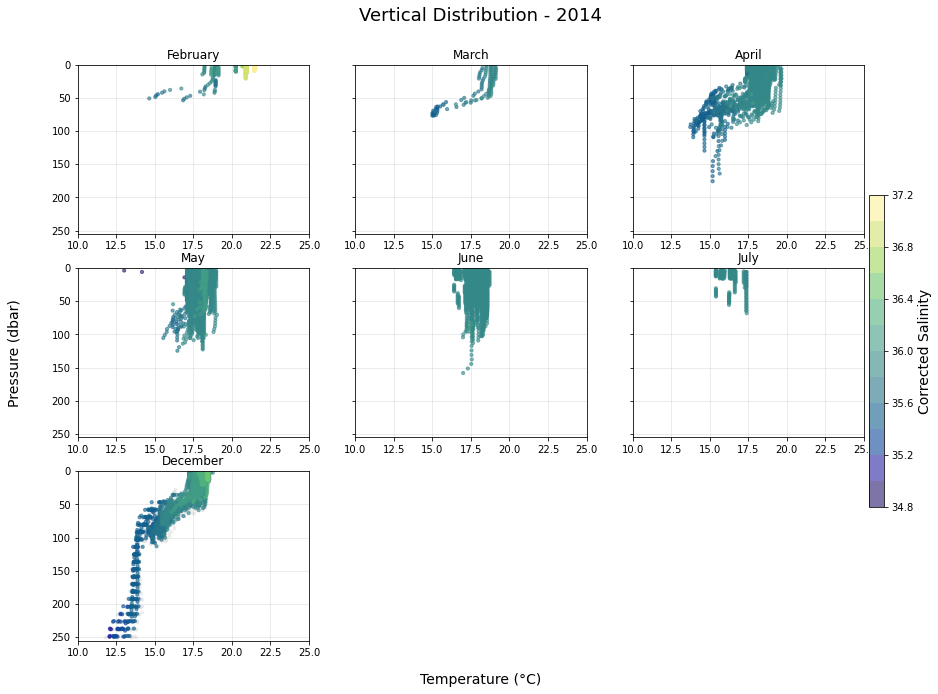

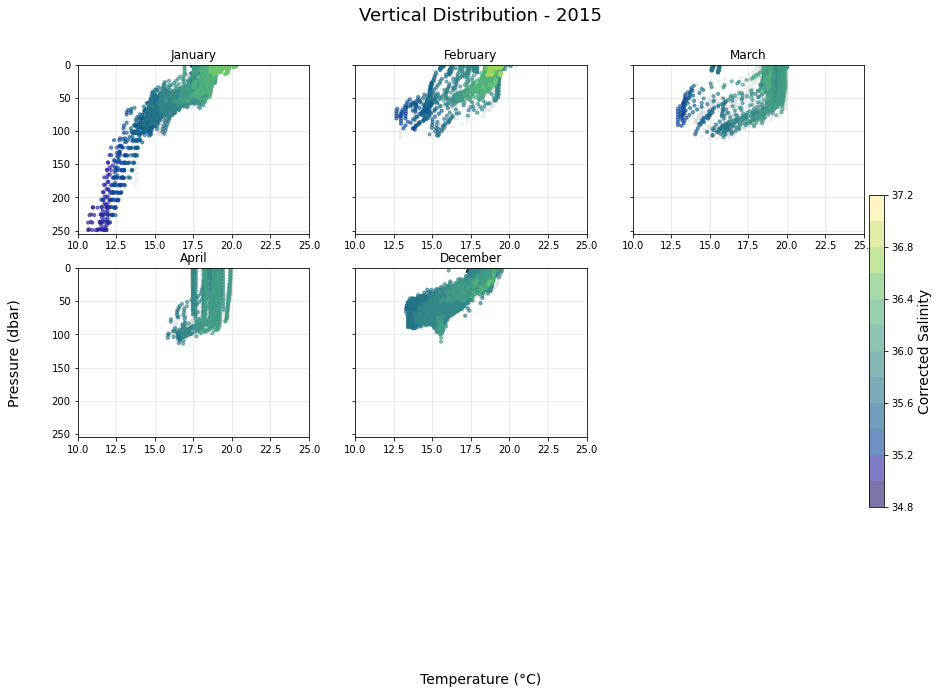

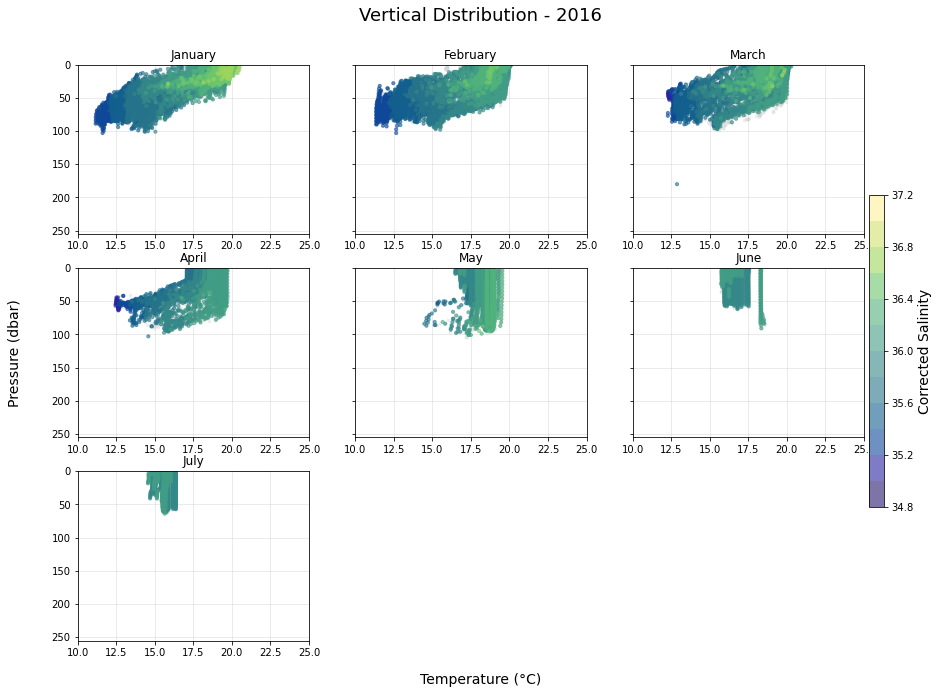

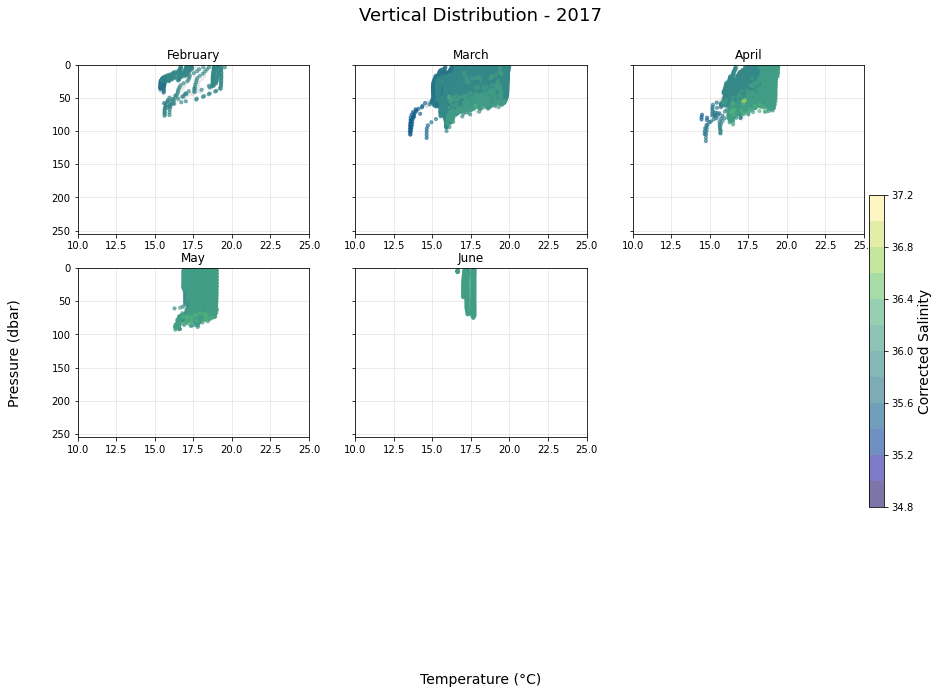

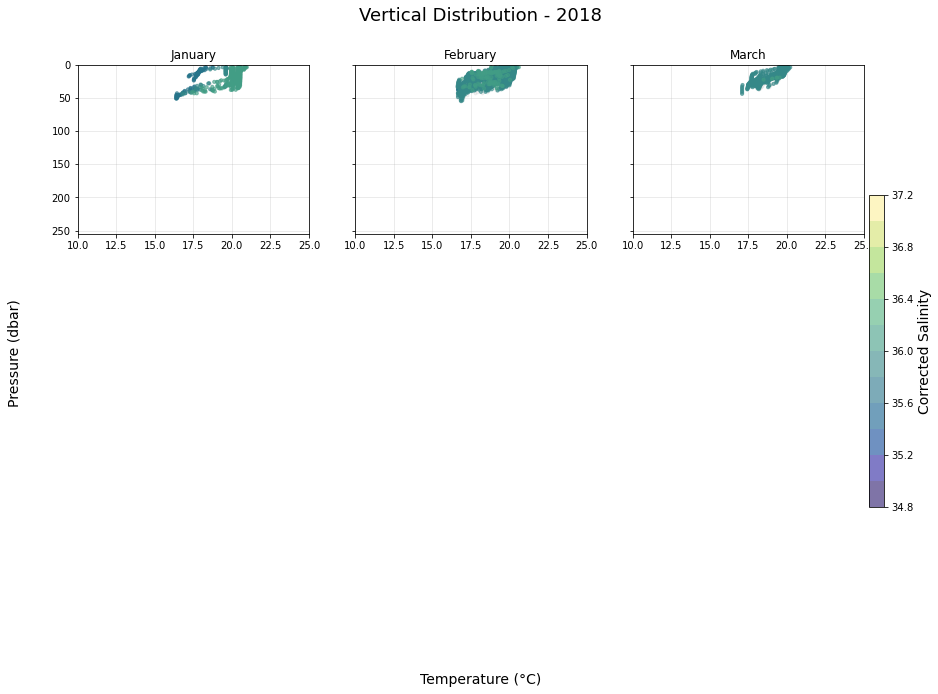

In [61]:
import matplotlib.pyplot as plt
import numpy as np
import cmocean
import matplotlib.colors as mcolors

data = df.copy()

years = np.sort(data['year'].unique())

# --- DEFINE DISCRETE BINS ---
bounds = np.arange(34.8, 37.2, 0.2)   # adjust if needed
norm = mcolors.BoundaryNorm(bounds, ncolors=256)

month_names = {
    1: 'January', 2: 'February', 3: 'March', 4: 'April',
    5: 'May', 6: 'June', 7: 'July', 8: 'August',
    9: 'September', 10: 'October', 11: 'November', 12: 'December'
}

for year in years:

    year_data = data[data['year'] == year]

    months = np.sort(year_data['month'].dropna().unique())

    if len(months) == 0:
        continue

    # --- FIXED LAYOUT (3x3) ---
    num_rows = 3
    num_cols = 3

    fig, axs = plt.subplots(num_rows, num_cols, figsize=(14, 10))
    axs = axs.flatten()

    figdir = r'C:\Users\nribeiro\OneDrive - University of Tasmania\IMOS Shared Docs\CAPSTAN 2025\CAPSTAN_HAB_work\Figures\\'
    
    sc = None  # for colorbar

    for i, month in enumerate(months):

        if i >= len(axs):
            break  # prevent overflow

        ax = axs[i]

        subset = year_data[year_data['month'] == month]

        # Only require temp + pressure
        subset = subset.dropna(subset=['pressure', 'temp_vals'])

        if len(subset) == 0:
            ax.set_visible(False)
            continue

        # --- SPLIT DATA ---
        mask = subset['sal_corrected_vals'].notna()

        # --- GREY POINTS FIRST (NaNs always behind) ---
        ax.scatter(
            subset.loc[~mask, 'temp_vals'],
            subset.loc[~mask, 'pressure'],
            color='lightgray',
            s=8,
            alpha=0.3,
            zorder=1
        )

        # --- SORT COLOURED DATA (low → high salinity) ---
        coloured = subset.loc[mask].sort_values('sal_corrected_vals')

        # --- COLOURED POINTS (on top) ---
        sc = ax.scatter(
            coloured['temp_vals'],
            coloured['pressure'],
            c=coloured['sal_corrected_vals'],
            cmap=cmocean.cm.haline,
            norm=norm,
            s=10,
            alpha=0.6,
            zorder=2
        )

        # Axis formatting
        ax.set_ylim(255, 0)
        ax.set_xlim(10, 25)  # adjust if needed

        ax.set_title(month_names.get(int(month), f'Month {int(month)}'), fontsize=12)
        ax.grid(True, linestyle='-', alpha=0.3)

        # Remove y labels except first column
        if i % num_cols != 0:
            ax.set_yticklabels([])

    # --- HIDE UNUSED PANELS ---
    for j in range(i + 1, len(axs)):
        axs[j].set_visible(False)

    # --- ONE SHARED DISCRETE COLORBAR ---
    if sc is not None:
        cbar = fig.colorbar(
            sc,
            ax=axs,
            orientation='vertical',
            fraction=0.02,
            pad=0.02,
            ticks=bounds
        )
        cbar.set_label('Corrected Salinity', fontsize=14)

        # Reduce clutter
        cbar.set_ticks(bounds[::2])

    # Labels
    fig.text(0.5, 0.04, 'Temperature (°C)', ha='center', fontsize=14)
    fig.text(0.03, 0.5, 'Pressure (dbar)', va='center', rotation='vertical', fontsize=14)
    fig.suptitle(f'Vertical Distribution - {year}', fontsize=18)

    fig.subplots_adjust(left=0.1, right=0.88, top=0.9, bottom=0.1)
    

    # --- SAVE FIGURE ---
    filename = f'vertical_distribution_{int(year)}.png'
    plt.savefig(
        figdir + filename,
        dpi=300,
        bbox_inches='tight',
        facecolor='white'
    )

    plt.show()